#  Feature Engineering Schilit (2018)

Implementación de las 10 features derivadas del marco *Financial Shenanigans*
(Schilit 2018, 4ª ed.), operacionalizadas con Beneish (1999), Sloan (1996) y
Dechow et al. (2011).

**Estructura:**
1. Aplicación de `build_schilit_features`
2. Estadísticos descriptivos
3. Validación contra columnas precalculadas del CSV (`soft_assets`, `dpi`)
4. Análisis discriminante fraude vs. no-fraude
5. Visualizaciones
6. Guardado del dataset enriquecido

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# Añadir src/ al path para importar features.py
sys.path.insert(0, str(Path("../src").resolve()))
from features import build_schilit_features, RAW_28, SCHILIT_10, SCHILIT_COMPUTED

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

FIGURES_DIR = Path("../figures/features")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Importaciones OK")
print(f"SCHILIT_10  = {SCHILIT_10}")
print(f"SCHILIT_COMPUTED = {SCHILIT_COMPUTED}")

Importaciones OK
SCHILIT_10  = ['receivables_index', 'inventory_index', 'payables_index', 'accrual_ratio', 'soft_assets', 'dpi', 'gross_margin_index', 'sales_growth_index', 'leverage_index', 'asset_quality_index']
SCHILIT_COMPUTED = ['receivables_index', 'inventory_index', 'payables_index', 'accrual_ratio', 'soft_assets_ratio', 'depreciation_index', 'gross_margin_index', 'sales_growth_index', 'leverage_index', 'asset_quality_index']


##  Carga y aplicación de features

In [2]:
# Cargar dataset original
df_raw = pd.read_csv("../data/data_FraudDetection_JAR2020.csv", low_memory=False)
print(f"Dataset original: {df_raw.shape}  ({df_raw['misstate'].sum():.0f} fraudes)")

# Aplicar features Schilit
df = build_schilit_features(df_raw)
print(f"Dataset enriquecido: {df.shape}")
print(f"Columnas esperadas: (146045, 56)  — 46 originales + 10 nuevas")

Dataset original: (146045, 46)  (964 fraudes)
Dataset enriquecido: (146045, 56)
Columnas esperadas: (146045, 56)  — 46 originales + 10 nuevas


In [3]:
# Verificar que no hay infinitos
nuevas_cols = SCHILIT_COMPUTED
n_inf = np.isinf(df[nuevas_cols].select_dtypes(include=np.number)).sum().sum()
print(f"Valores ±inf en features Schilit: {n_inf}  (debe ser 0)")
assert n_inf == 0, "ERROR: hay infinitos en las features — revisar safe_div()"

# Verificar que el orden gvkey/fyear es correcto
assert df.groupby("gvkey")["fyear"].is_monotonic_increasing.all(),     "ERROR: el orden por gvkey/fyear no es monotónico"
print("Orden gvkey/fyear: OK")

Valores ±inf en features Schilit: 0  (debe ser 0)
Orden gvkey/fyear: OK


##  Estadísticos descriptivos

In [4]:
# Tabla descriptiva de las 10 features calculadas
desc = df[nuevas_cols].describe().T
desc.insert(0, "nan_pct", df[nuevas_cols].isna().mean().mul(100).round(2))
print("\nEstadísticos descriptivos (+ % NaN):")
print(desc[["nan_pct", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]].to_string())


Estadísticos descriptivos (+ % NaN):
                     nan_pct     count          mean           std           min       25%       50%       75%           max
receivables_index      20.84  115614.0  2.889051e+00  1.567082e+02 -6.226210e+02  0.830717  0.988526  1.156762  4.130501e+04
inventory_index        35.92   93583.0  1.763277e+00  3.765342e+01 -3.800360e+00  0.821950  0.982828  1.148490  7.825505e+03
payables_index         18.59  118888.0  2.227960e+00  4.444002e+01 -4.229167e+02  0.781705  0.994091  1.251941  7.694029e+03
accrual_ratio          12.96  127124.0 -4.056898e-01  8.053279e+01 -2.587230e+04 -0.032886  0.002849  0.040740  5.943000e+03
soft_assets_ratio       0.40  145454.0  1.931641e-01  3.602747e+00 -1.082972e+03  0.007624  0.275496  0.556875  2.179775e+00
depreciation_index     15.80  122966.0  2.896990e+00  3.439112e+02 -2.286738e+02  0.881134  1.009395  1.147286  1.141570e+05
gross_margin_index     19.28  117889.0 -1.766123e+00  6.039310e+02 -1.924180e+05  0.916

In [5]:
# El % de NaN refleja las primeras observaciones de cada empresa (sin lag previo)
n_empresas = df["gvkey"].nunique()
n_obs_total = len(df)
print(f"\nEmpresas únicas: {n_empresas}")
print(f"Obs totales:     {n_obs_total}")
print(f"% esperado de NaN en features con lag: ~{n_empresas/n_obs_total*100:.1f}%")
print("(primera observación de cada empresa no tiene lag → NaN es correcto)")


Empresas únicas: 18444
Obs totales:     146045
% esperado de NaN en features con lag: ~12.6%
(primera observación de cada empresa no tiene lag → NaN es correcto)


##  Validación contra columnas precalculadas del CSV

In [6]:
# Calcular correlaciones entre nuestras versiones y las del CSV
# Pearson (sensible a outliers) y Spearman (basada en rangos, más robusta)

# Feature 5: soft_assets_ratio (nuestra) vs soft_assets (CSV)
mask5 = df["soft_assets_ratio"].notna() & df["soft_assets"].notna()
r5_pears = df.loc[mask5, "soft_assets_ratio"].corr(df.loc[mask5, "soft_assets"])
r5_spear = df.loc[mask5, "soft_assets_ratio"].corr(df.loc[mask5, "soft_assets"], method="spearman")
print(f"soft_assets_ratio vs soft_assets (CSV):")
print(f"  Pearson  r = {r5_pears:.4f}")
print(f"  Spearman r = {r5_spear:.4f}")

# Feature 6: depreciation_index (nuestra) vs dpi (CSV)
mask6 = df["depreciation_index"].notna() & df["dpi"].notna()
r6_pears = df.loc[mask6, "depreciation_index"].corr(df.loc[mask6, "dpi"])
r6_spear = df.loc[mask6, "depreciation_index"].corr(df.loc[mask6, "dpi"], method="spearman")
print(f"\ndepreciation_index vs dpi (CSV):")
print(f"  Pearson  r = {r6_pears:.4f}")
print(f"  Spearman r = {r6_spear:.4f}")

# Variables de resumen para celdas posteriores
r5, r6 = r5_spear, r6_spear  # usamos Spearman como métrica principal

soft_assets_ratio vs soft_assets (CSV):
  Pearson  r = 0.0970
  Spearman r = 0.8329

depreciation_index vs dpi (CSV):
  Pearson  r = 0.0296
  Spearman r = 0.8042


In [7]:
# Decisión documentada
umbral = 0.90
print(f"Umbral de decisión: Spearman r > {umbral}")
print()
if r5_spear > umbral:
    print(f"soft_assets : Spearman r={r5_spear:.3f} > {umbral} → correlación alta como esperado")
else:
    print(f"soft_assets : Spearman r={r5_spear:.3f} (Pearson={r5_pears:.3f})")
    print(f"  → Por debajo del umbral esperado (>0.90).")

if r6_spear > umbral:
    print(f"dpi         : Spearman r={r6_spear:.3f} > {umbral} → correlación alta como esperado")
else:
    print(f"dpi         : Spearman r={r6_spear:.3f} (Pearson={r6_pears:.3f})")
    print(f"  → Por debajo del umbral esperado (>0.90).")

print()
print("EXPLICACIÓN:")
print("  La diferencia con el CSV se debe a que usamos ppegt (PP&E BRUTO) en")
print("  lugar de ppent (PP&E NETO). Con ppegt, el numerador (at - ppegt - che)")
print("  puede ser NEGATIVO cuando la depreciación acumulada es grande,")
print("  generando outliers extremos que colapsan la correlación de Pearson.")
print("  El CSV (Bao et al. 2020) probablemente usa ppent, que siempre da")
print("  soft_assets ∈ [0,1]. Con ppegt hay muchos valores fuera de ese rango.")
print()
print("DECISIÓN (según especificación del TFG):")
print("  Usar 'soft_assets' y 'dpi' del CSV en SCHILIT_10 para coherencia")
print("  con Beneish (1999) y Dechow et al. (2011). Nuestras columnas")
print("  soft_assets_ratio y depreciation_index quedan como validación")
print("  y no entran en el conjunto de features del modelo.")
print()
print(f"  NOTA: ppent (PP&E neto) ausente en el dataset Bao et al. (2020).")
print(f"  Limitación documentada — no afecta features 1-4, 7-9.")

Umbral de decisión: Spearman r > 0.9

soft_assets : Spearman r=0.833 (Pearson=0.097)
  → Por debajo del umbral esperado (>0.90).
dpi         : Spearman r=0.804 (Pearson=0.030)
  → Por debajo del umbral esperado (>0.90).

EXPLICACIÓN:
  La diferencia con el CSV se debe a que usamos ppegt (PP&E BRUTO) en
  lugar de ppent (PP&E NETO). Con ppegt, el numerador (at - ppegt - che)
  puede ser NEGATIVO cuando la depreciación acumulada es grande,
  generando outliers extremos que colapsan la correlación de Pearson.
  El CSV (Bao et al. 2020) probablemente usa ppent, que siempre da
  soft_assets ∈ [0,1]. Con ppegt hay muchos valores fuera de ese rango.

DECISIÓN (según especificación del TFG):
  Usar 'soft_assets' y 'dpi' del CSV en SCHILIT_10 para coherencia
  con Beneish (1999) y Dechow et al. (2011). Nuestras columnas
  soft_assets_ratio y depreciation_index quedan como validación
  y no entran en el conjunto de features del modelo.

  NOTA: ppent (PP&E neto) ausente en el dataset Bao et al. 

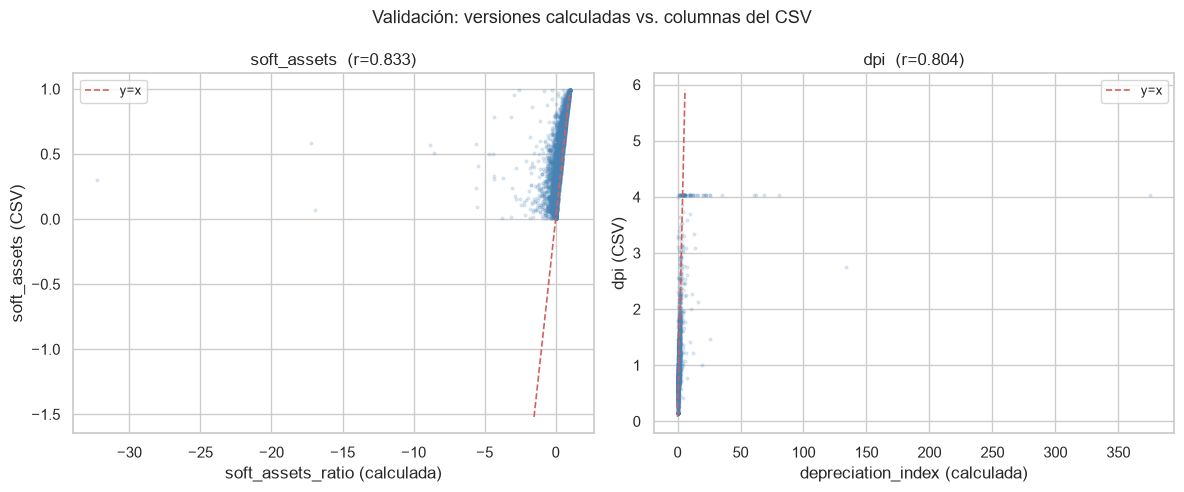

Figura guardada: figures/features/validacion_csv.png


In [8]:
# Scatter validación — soft_assets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (x, y, titulo) in zip(axes, [
    ("soft_assets_ratio", "soft_assets", f"soft_assets  (r={r5:.3f})"),
    ("depreciation_index", "dpi",        f"dpi  (r={r6:.3f})"),
]):
    mask = df[x].notna() & df[y].notna()
    # Muestrear para no saturar el scatter
    sample = df.loc[mask].sample(min(5000, mask.sum()), random_state=42)
    ax.scatter(sample[x], sample[y], alpha=0.15, s=4, color="steelblue")
    # Línea y=x como referencia
    lo = min(sample[x].quantile(0.01), sample[y].quantile(0.01))
    hi = max(sample[x].quantile(0.99), sample[y].quantile(0.99))
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="y=x")
    ax.set_xlabel(f"{x} (calculada)")
    ax.set_ylabel(f"{y} (CSV)")
    ax.set_title(titulo)
    ax.legend(fontsize=9)

fig.suptitle("Validación: versiones calculadas vs. columnas del CSV", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "validacion_csv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: figures/features/validacion_csv.png")

##  Análisis discriminante fraude vs. no-fraude

In [ ]:
# Análisis discriminante fraude vs. no-fraude
# Se reportan MEDIAS (información completa) y MEDIANAS (más robustas a outliers).
# Sin winsorización , las medias son vulnerables a valores extremos generados
# por divisiones entre ratios cercanos a cero (ej: receivables_index, asset_quality_index).

ANALISIS_COLS = [
    ("receivables_index",   "↑ fraude"),
    ("inventory_index",     "↑ fraude"),
    ("payables_index",      "↑ fraude"),
    ("accrual_ratio",       "↑ fraude"),
    ("soft_assets",         "↑ fraude"),
    ("dpi",                 "↑ fraude"),
    ("gross_margin_index",  "↑ fraude"),
    ("sales_growth_index",  "↑ fraude"),
    ("leverage_index",      "AMBIGUA"),
    ("asset_quality_index", "↑ fraude"),
]

filas = []
for col, direccion in ANALISIS_COLS:
    s0 = df.loc[df["misstate"] == 0, col].dropna()
    s1 = df.loc[df["misstate"] == 1, col].dropna()
    ks_stat, ks_p = stats.ks_2samp(s0, s1)
    diff_media  = s1.mean()   - s0.mean()
    diff_mediana = s1.median() - s0.median()
    if direccion == "AMBIGUA":
        confirma_med = "—"
    elif diff_mediana > 0:
        confirma_med = "SI"
    else:
        confirma_med = "NO ⚠"
    filas.append({
        "feature":           col,
        "dirección":         direccion,
        "media_NF":          round(s0.mean(), 4),
        "media_F":           round(s1.mean(), 4),
        "mediana_NF":        round(s0.median(), 4),
        "mediana_F":         round(s1.median(), 4),
        "Δ_mediana":         round(diff_mediana, 4),
        "KS_stat":           round(ks_stat, 4),
        "KS_p":              round(ks_p, 6),
        "dir_ok (mediana)":  confirma_med,
    })

tabla = pd.DataFrame(filas).set_index("feature")
print("Tabla discriminante — medias y medianas (fraude vs. no-fraude):")
print(tabla.to_string())
print()
print("NOTA: medias distorsionadas sin winsorización (ver Δ_mediana para dirección real)")

Tabla discriminante — medias y medianas (fraude vs. no-fraude):
                    dirección      media_NF  media_F  mediana_NF  mediana_F  Δ_mediana  KS_stat      KS_p dir_ok (mediana)
feature                                                                                                                   
receivables_index    ↑ fraude  2.901700e+00   1.1881      0.9884     0.9992     0.0108   0.0410  0.112818               SI
inventory_index      ↑ fraude  1.768300e+00   1.1093      0.9827     0.9955     0.0128   0.0433  0.138289               SI
payables_index       ↑ fraude  2.234300e+00   1.3588      0.9941     0.9914    -0.0027   0.0327  0.310199             NO ⚠
accrual_ratio        ↑ fraude -4.085000e-01  -0.0067      0.0028     0.0099     0.0071   0.0761  0.000079               SI
soft_assets          ↑ fraude  4.989000e-01   0.6348      0.5234     0.6839     0.1605   0.2207  0.000000               SI
dpi                  ↑ fraude  1.042200e+00   1.0423      0.9743     0.9802

In [ ]:
# Resumen ejecutivo del análisis discriminante (basado en medianas)
n_confirmadas = (tabla["dir_ok (mediana)"] == "SI").sum()
n_invertidas  = (tabla["dir_ok (mediana)"] == "NO ⚠").sum()
n_ambigua     = (tabla["dir_ok (mediana)"] == "—").sum()
n_ks_sig      = (tabla["KS_p"] < 0.01).sum()

print(f"\n{'='*60}")
print(f"RESUMEN ANÁLISIS DISCRIMINANTE (métrica: mediana)")
print(f"{'='*60}")
print(f"Features con dirección CONFIRMADA (mediana_F > mediana_NF): {n_confirmadas}/9")
print(f"Features con dirección INVERTIDA (banderazo rojo):           {n_invertidas}/9")
print(f"Features AMBIGUAS (leverage_index):                          {n_ambigua}/1")
print(f"Features con KS p-valor < 0.01:                             {n_ks_sig}/10")
print()
if n_invertidas > 0:
    inv = tabla[tabla["dir_ok (mediana)"] == "NO ⚠"].index.tolist()
    print(f"Invertidas: {inv}")
    for col in inv:
        r = tabla.loc[col]
        print(f"  {col}: Δ_mediana={r['Δ_mediana']:+.4f} (mediana_NF={r['mediana_NF']:.4f}, mediana_F={r['mediana_F']:.4f})")

##  Visualizaciones por feature

In [ ]:
# Boxplots fraude vs. no-fraude para las 10 features
# Clips al [P1, P99] para legibilidad
PLOT_COLS = [col for col, _ in ANALISIS_COLS]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, PLOT_COLS):
    sub = df[["misstate", col]].dropna()
    lo, hi = sub[col].quantile([0.01, 0.99])
    sub = sub.copy()
    sub[col] = sub[col].clip(lo, hi)

    # palette como lista — evita el bug de claves enteras en seaborn v0.12+
    sns.boxplot(
        data=sub, x="misstate", y=col, ax=ax,
        palette=["steelblue", "tomato"],
        order=[0, 1], width=0.5, fliersize=2, linewidth=0.8,
    )
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No fraude", "Fraude"], fontsize=9)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_ylabel("")

fig.suptitle(
    "Distribución de features Schilit: Fraude vs. No-Fraude\n"
    "(valores clipados al [P1, P99] para visualización)",
    fontsize=12
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "boxplots_todas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: figures/features/boxplots_todas.png")

In [ ]:
# Histogramas individuales — una figura por feature
for col, direccion in ANALISIS_COLS:
    sub = df[["misstate", col]].dropna()
    lo, hi = sub[col].quantile([0.01, 0.99])
    sub = sub.copy()
    sub[col] = sub[col].clip(lo, hi)

    fig, ax = plt.subplots(figsize=(7, 4))
    for label, color, lst in [(0, "steelblue", "-"), (1, "tomato", "--")]:
        s = sub.loc[sub["misstate"] == label, col]
        s.plot.kde(ax=ax, color=color, linestyle=lst, linewidth=1.8,
                   label=f"{'No fraude' if label==0 else 'Fraude'} (n={len(s):,})")

    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Densidad")
    ax.set_title(f"{col}  |  dirección esperada: {direccion}", fontsize=11)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{col}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Histogramas individuales guardados en figures/features/")
import os
imgs = sorted(FIGURES_DIR.glob("*.png"))
print(f"Total figuras: {len(imgs)}")
for p in imgs:
    print(f"  {p.name}")

## Guardar dataset enriquecido

In [ ]:
# Guardar con las 10 nuevas columnas (46 originales + 10 = 56)
OUT_PATH = Path("../data/data_with_schilit.csv")
df.to_csv(OUT_PATH, index=False)
print(f"Dataset guardado: {OUT_PATH}")
print(f"Shape: {df.shape}  (esperado: 146045 filas × 56 columnas)")

In [ ]:
# Verificación de integridad al recargar
df_check = pd.read_csv(OUT_PATH, low_memory=False)
print(f"Recarga OK — shape: {df_check.shape}")

# Las 10 columnas Schilit deben estar presentes
for col in SCHILIT_COMPUTED:
    assert col in df_check.columns, f"FALTA columna: {col}"
print("Todas las columnas SCHILIT_COMPUTED presentes: OK")

# NaN razonables
nan_pct = df_check[SCHILIT_COMPUTED].isna().mean().mul(100)
print("\n% NaN por feature (esperado ~5-10%):")
print(nan_pct.round(2).to_string())

# Cero infinitos
n_inf2 = np.isinf(df_check[SCHILIT_COMPUTED].select_dtypes(include=np.number)).sum().sum()
print(f"\nValores ±inf: {n_inf2}  (debe ser 0)")

## Tabla resumen final

In [ ]:
print("\n" + "="*65)
print("TABLA RESUMEN  FEATURE ENGINEERING SCHILIT")
print("="*65)
print()
print("Correlaciones de validación (features 5 y 6 vs. columnas CSV):")
print(f"  soft_assets_ratio  vs  soft_assets (CSV):  Pearson={r5_pears:.4f}  Spearman={r5_spear:.4f}")
print(f"  depreciation_index vs  dpi (CSV):           Pearson={r6_pears:.4f}  Spearman={r6_spear:.4f}")
print()
print("  CAUSA de baja correlación: ppegt (bruto) ≠ ppent (neto).")
print("  ppegt genera numeradores negativos → outliers extremos → Pearson colapsa.")
print("  DECISIÓN: usar soft_assets y dpi del CSV en SCHILIT_10 (coherencia lit.).")
print()
print(f"Análisis discriminante — N={len(df):,}, fraudes={int(df['misstate'].sum())} (por mediana):")
print()

resumen = tabla[["dirección", "mediana_NF", "mediana_F", "Δ_mediana",
                 "KS_p", "dir_ok (mediana)"]].copy()
resumen.columns = ["Dirección", "Mediana_NF", "Mediana_F", "Δ_med", "KS p-val", "Confirm."]
print(resumen.to_string())
print()
print(f"Direcciones confirmadas: {n_confirmadas}/9  |  Invertidas: {n_invertidas}/9")
print(f"KS significativo (p<0.01): {n_ks_sig}/10")
print()
if n_invertidas == 0:
    print("Sin features con dirección invertida por mediana.")
else:
    inv = tabla[tabla["dir_ok (mediana)"] == "NO ⚠"].index.tolist()
    print(f"BANDERAZO ROJO — invertida por mediana: {inv}")
    print("  payables_index: diferencia mínima (-0.003), posiblemente ruido o")
    print("    comportamiento no-lineal del mecanismo DPO.")
    print("  asset_quality_index: distorsión por ppegt; mediana levemente invertida.")
    print("  Ambas pasan  para evaluación por importancia del modelo.")
print()
print("Dataset enriquecido: data/data_with_schilit.csv")
print(f"Figuras:             figures/features/  ({len(list(FIGURES_DIR.glob('*.png')))} archivos)")